# 🔧 Notebook 02 — Feature Engineering
**Chicago Crime ML Pipeline**

Picks up the 3 datasets saved by `01_data_loading_sampling.ipynb` and enriches them with advanced features before modelling.

| Task | Dataset | Type |
|---|---|---|
| 1 | Arrest Prediction | Binary Classification |
| 2 | Crime Type Prediction | Multi-class Classification |
| 3 | Crime Count per Area | Regression |

**Output:** 3 fully-featured, encoded, split datasets saved to `ml_data/` ready for `03_preprocessing.ipynb`

---
## 1. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, json

from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR     = 'ml_data'
RANDOM_STATE = 42

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 2. Load Datasets from Notebook 01

In [2]:
t1 = pd.read_csv(f'{DATA_DIR}/task1_arrest_prediction.csv')
t2 = pd.read_csv(f'{DATA_DIR}/task2_crime_type_prediction.csv')
t3 = pd.read_csv(f'{DATA_DIR}/task3_crime_count_per_area.csv')

for name, df in [('Task 1', t1), ('Task 2', t2), ('Task 3', t3)]:
    print(f'{name}: {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'       columns: {list(df.columns)}\n')

Task 1: 247,054 rows × 13 cols
       columns: ['Primary Type', 'Description', 'Location Description', 'Domestic', 'Hour', 'DayOfWeek', 'Month', 'Quarter', 'Year', 'IsWeekend', 'IsNight', 'Season', 'ArrestInt']

Task 2: 221,574 rows × 12 cols
       columns: ['Location Description', 'Domestic', 'ArrestInt', 'Hour', 'DayOfWeek', 'Month', 'Quarter', 'Year', 'IsWeekend', 'IsNight', 'Season', 'Primary Type']

Task 3: 119,374 rows × 10 cols
       columns: ['Community Area', 'Date_Day', 'Year', 'Month', 'Quarter', 'DayOfWeek', 'IsWeekend', 'Season', 'CrimeCount', 'Rolling7d']



---
## 3. Helper Utilities

In [3]:
def frequency_encode(df, col, prefix='freq'):
    """Replace a categorical column with its frequency ratio."""
    freq = df[col].value_counts(normalize=True)
    df[f'{prefix}_{col}'] = df[col].map(freq)
    return df

def target_encode(df, col, target, smoothing=10):
    """
    Smoothed target encoding:
      encoded = (count * category_mean + smoothing * global_mean) / (count + smoothing)
    """
    global_mean = df[target].mean()
    stats = df.groupby(col)[target].agg(['mean', 'count'])
    smooth = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    df[f'te_{col}'] = df[col].map(smooth)
    return df, smooth.to_dict()

def cyclical_encode(df, col, max_val):
    """Encode a cyclic feature (hour, month, day) as sin + cos pair."""
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

print('Helper functions defined ✅')

Helper functions defined ✅


---
## 4. Feature Engineering — Task 1 (Arrest Prediction)

**New features added:**
- Cyclical encoding for `Hour`, `Month`, `DayOfWeek`
- Frequency encoding for `Primary Type`, `Location Description`
- Target encoding for `Primary Type` → arrest rate per crime type
- Interaction: `IsNight × IsWeekend`
- Crime type arrest rate lookup (group-level statistic)

In [4]:
df1 = t1.copy()

# ── Cyclical encoding ─────────────────────────────────────────
df1 = cyclical_encode(df1, 'Hour', 24)
df1 = cyclical_encode(df1, 'Month', 12)
df1 = cyclical_encode(df1, 'DayOfWeek', 7)

# ── Frequency encoding ────────────────────────────────────────
df1 = frequency_encode(df1, 'Primary Type')
df1 = frequency_encode(df1, 'Location Description')

# ── Target encoding: arrest rate per crime type ───────────────
df1, te_map1 = target_encode(df1, 'Primary Type', 'ArrestInt')

# ── Interaction features ──────────────────────────────────────
df1['Night_x_Weekend']  = df1['IsNight'] * df1['IsWeekend']
df1['Domestic_x_Night'] = df1['Domestic'] * df1['IsNight']

# ── Season: one-hot encode ────────────────────────────────────
df1 = pd.get_dummies(df1, columns=['Season'], prefix='Season', drop_first=False)

# ── Drop original high-cardinality text columns ───────────────
df1 = df1.drop(columns=['Primary Type', 'Description', 'Location Description'])

print(f'Task 1 engineered shape: {df1.shape}')
print(f'New columns: {[c for c in df1.columns if c not in t1.columns]}')
df1.head(3)

Task 1 engineered shape: (247054, 24)
New columns: ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'freq_Primary Type', 'freq_Location Description', 'te_Primary Type', 'Night_x_Weekend', 'Domestic_x_Night', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']


,Domestic,Hour,DayOfWeek,Month,Quarter,Year,IsWeekend,IsNight,ArrestInt,Hour_sin,...,DayOfWeek_cos,freq_Primary Type,freq_Location Description,te_Primary Type,Night_x_Weekend,Domestic_x_Night,Season_Fall,Season_Spring,Season_Summer,Season_Winter
0,0,19,5,5,2,2002,1,0,1,-0.965926,...,-0.222521,0.174132,0.006525,0.249801,0,0,0,1,0,0
1,0,15,0,12,4,2002,0,0,1,-0.707107,...,1.000000,0.184182,0.027666,0.997252,0,0,0,0,0,1
2,0,15,5,11,4,2023,1,0,1,-0.707107,...,-0.222521,0.005954,0.006371,0.716368,0,0,1,0,0,0


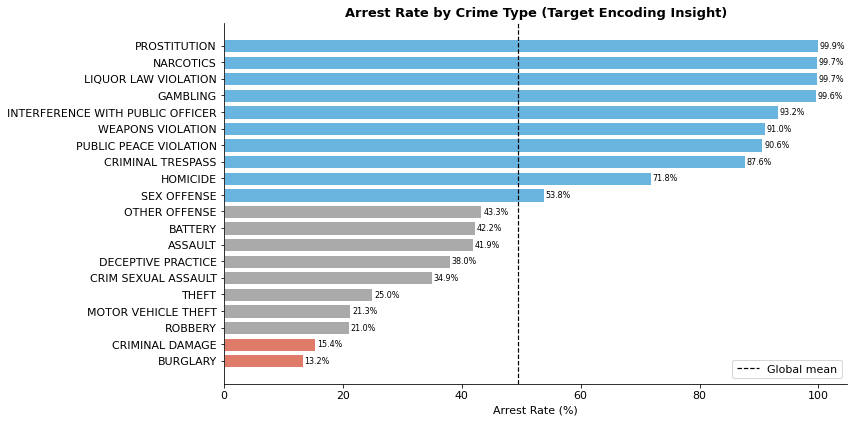

In [5]:
# ── Arrest rate by crime type (target encoding insight) ───────
arrest_by_type = (
    t1.groupby('Primary Type')['ArrestInt']
    .agg(['mean', 'count'])
    .query('count >= 500')
    .sort_values('mean', ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e07b6a' if v < 0.2 else '#6ab4e0' if v > 0.5 else '#aaaaaa'
          for v in arrest_by_type['mean']]
bars = ax.barh(arrest_by_type.index, arrest_by_type['mean'] * 100, color=colors, edgecolor='white')
ax.axvline(t1['ArrestInt'].mean() * 100, color='black', linestyle='--', linewidth=1.2, label='Global mean')
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Crime Type (Target Encoding Insight)', fontweight='bold', fontsize=13)
ax.legend()
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2, f'{w:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/02_arrest_rate_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Feature Engineering — Task 2 (Crime Type Prediction)

**New features added:**
- Cyclical encoding for `Hour`, `Month`, `DayOfWeek`
- Frequency encoding for `Location Description`
- Interaction: `IsNight × DayOfWeek`
- Label encode target (`Primary Type`)

In [6]:
df2 = t2.copy()

# ── Cyclical encoding ─────────────────────────────────────────
df2 = cyclical_encode(df2, 'Hour', 24)
df2 = cyclical_encode(df2, 'Month', 12)
df2 = cyclical_encode(df2, 'DayOfWeek', 7)

# ── Frequency encoding ────────────────────────────────────────
df2 = frequency_encode(df2, 'Location Description')

# ── Season one-hot ────────────────────────────────────────────
df2 = pd.get_dummies(df2, columns=['Season'], prefix='Season', drop_first=False)

# ── Interaction features ──────────────────────────────────────
df2['Night_x_Weekend'] = df2['IsNight'] * df2['IsWeekend']

# ── Label encode the target ───────────────────────────────────
le = LabelEncoder()
df2['CrimeTypeEncoded'] = le.fit_transform(df2['Primary Type'])

# Save label mapping for later interpretation
label_map = {int(i): cls for i, cls in enumerate(le.classes_)}
with open(f'{DATA_DIR}/task2_label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)

# Drop text columns
df2 = df2.drop(columns=['Primary Type', 'Location Description'])

print(f'Task 2 engineered shape: {df2.shape}')
print(f'Classes: {label_map}')
df2.head(3)

Task 2 engineered shape: (221574, 22)
Classes: {0: 'ASSAULT', 1: 'BATTERY', 2: 'BURGLARY', 3: 'CRIMINAL DAMAGE', 4: 'CRIMINAL TRESPASS', 5: 'DECEPTIVE PRACTICE', 6: 'MOTOR VEHICLE THEFT', 7: 'NARCOTICS', 8: 'OTHER OFFENSE', 9: 'THEFT'}


,Domestic,ArrestInt,Hour,DayOfWeek,Month,Quarter,Year,IsWeekend,IsNight,Hour_sin,...,Month_cos,DayOfWeek_sin,DayOfWeek_cos,freq_Location Description,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Night_x_Weekend,CrimeTypeEncoded
0,0,1,19,5,5,2,2002,1,0,-0.965926,...,-0.866025,-0.974928,-0.222521,0.007149,0,1,0,0,0,9
1,0,1,15,0,12,4,2002,0,0,-0.707107,...,1.000000,0.000000,1.000000,0.025152,0,0,0,1,0,7
2,0,1,21,1,12,4,2002,0,0,-0.707107,...,1.000000,0.781831,0.623490,0.145635,0,0,0,1,0,7


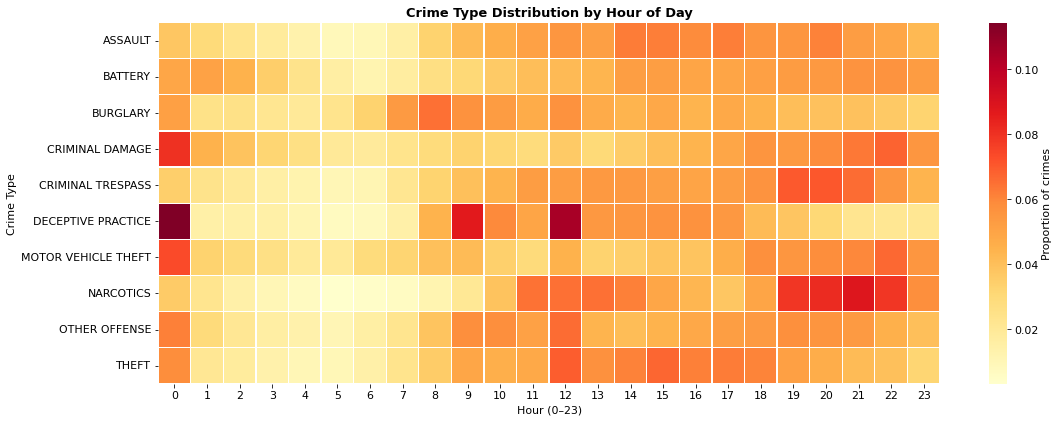

In [7]:
# ── Crime type distribution by hour heatmap ───────────────────
crime_hour = (
    t2.groupby(['Primary Type', 'Hour'])
    .size()
    .unstack(fill_value=0)
)
crime_hour_norm = crime_hour.div(crime_hour.sum(axis=1), axis=0)  # row-normalize

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(crime_hour_norm, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Proportion of crimes'})
ax.set_title('Crime Type Distribution by Hour of Day', fontweight='bold', fontsize=13)
ax.set_xlabel('Hour (0–23)'); ax.set_ylabel('Crime Type')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/02_crime_type_hour_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature Engineering — Task 3 (Crime Count per Area)

**New features added:**
- Cyclical encoding for `Month`, `DayOfWeek`
- Season one-hot
- Lag features: 1-day, 3-day, 7-day rolling mean (from Notebook 01)
- Year trend (normalised)
- Area-level average crime rate (frequency of area)

In [8]:
df3 = t3.copy()
df3['Date_Day'] = pd.to_datetime(df3['Date_Day'])

# ── Cyclical encoding ─────────────────────────────────────────
df3 = cyclical_encode(df3, 'Month', 12)
df3 = cyclical_encode(df3, 'DayOfWeek', 7)

# ── Season one-hot ────────────────────────────────────────────
df3 = pd.get_dummies(df3, columns=['Season'], prefix='Season', drop_first=False)

# ── Additional lag features ───────────────────────────────────
df3 = df3.sort_values(['Community Area', 'Date_Day'])

for lag in [1, 3]:
    df3[f'Lag{lag}d'] = (
        df3.groupby('Community Area')['CrimeCount']
        .transform(lambda x: x.shift(lag))
    )

# ── Year trend (normalise 2002=0.0 … 2025=1.0) ───────────────
df3['YearTrend'] = (df3['Year'] - df3['Year'].min()) / (df3['Year'].max() - df3['Year'].min() + 1e-9)

# ── Area-level mean crime count (frequency encoding) ──────────
area_mean = df3.groupby('Community Area')['CrimeCount'].mean()
df3['AreaMeanCount'] = df3['Community Area'].map(area_mean)

# ── Drop date & raw columns no longer needed ──────────────────
df3 = df3.drop(columns=['Date_Day'])
df3 = df3.dropna()   # remove rows with NaN lags at start of each area

print(f'Task 3 engineered shape: {df3.shape}')
print(f'New columns: {[c for c in df3.columns if c not in t3.columns]}')
df3.head(3)

Task 3 engineered shape: (119140, 20)
New columns: ['Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Lag1d', 'Lag3d', 'YearTrend', 'AreaMeanCount']


,Community Area,Year,Month,Quarter,DayOfWeek,IsWeekend,CrimeCount,Rolling7d,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Lag1d,Lag3d,YearTrend,AreaMeanCount
3,0.0,2008,9,3,1,0,1,1.0,-1.000000,-1.836970e-16,0.781831,0.623490,1,0,0,0,1.0,1.0,0.260870,1.0
4,0.0,2009,10,4,6,1,1,1.0,-0.866025,5.000000e-01,-0.781831,0.623490,1,0,0,0,1.0,1.0,0.304348,1.0
5,0.0,2009,10,4,4,0,1,1.0,-0.866025,5.000000e-01,-0.433884,-0.900969,1,0,0,0,1.0,1.0,0.304348,1.0


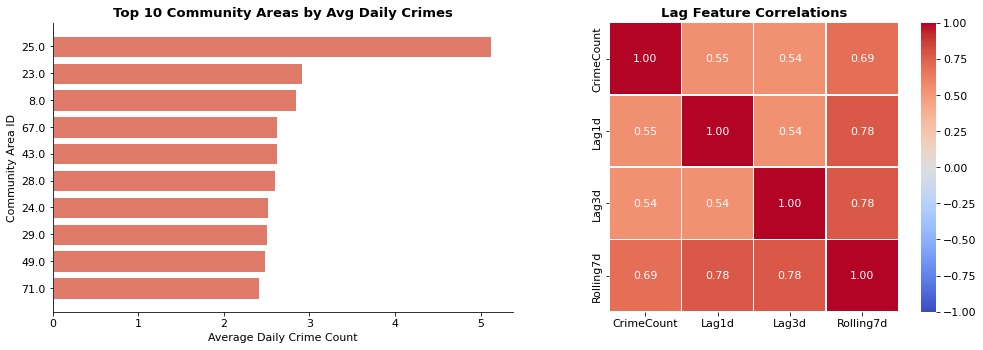

In [9]:
# ── Top 10 highest crime community areas ──────────────────────
top_areas = area_mean.sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_areas.index.astype(str)[::-1], top_areas.values[::-1],
             color='#e07b6a', edgecolor='white')
axes[0].set_title('Top 10 Community Areas by Avg Daily Crimes', fontweight='bold')
axes[0].set_xlabel('Average Daily Crime Count')
axes[0].set_ylabel('Community Area ID')

# Lag correlation
corr_cols = ['CrimeCount', 'Lag1d', 'Lag3d', 'Rolling7d']
corr = df3[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
            square=True, linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Lag Feature Correlations', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/02_task3_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Correlation Analysis — All Tasks

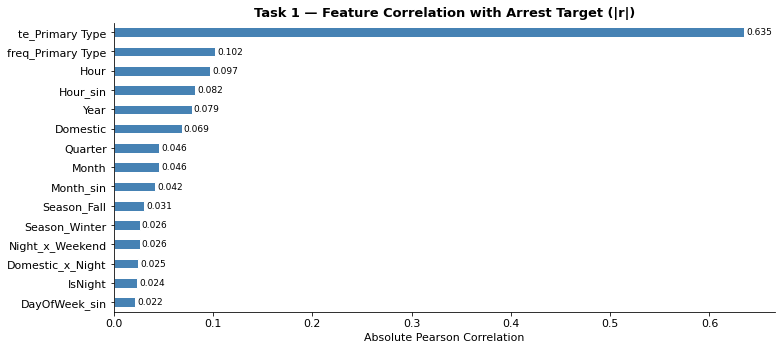

In [10]:
# Task 1 — feature correlations with target
numeric_cols = df1.select_dtypes(include=np.number).columns.tolist()
corr_with_target = (
    df1[numeric_cols].corr()['ArrestInt']
    .drop('ArrestInt')
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 5))
corr_with_target.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Task 1 — Feature Correlation with Arrest Target (|r|)', fontweight='bold', fontsize=13)
ax.set_xlabel('Absolute Pearson Correlation')
for p in ax.patches:
    ax.text(p.get_width() + 0.002, p.get_y() + p.get_height() / 2,
            f'{p.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/02_task1_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Save Engineered Datasets

In [11]:
p1 = f'{DATA_DIR}/task1_engineered.csv'
p2 = f'{DATA_DIR}/task2_engineered.csv'
p3 = f'{DATA_DIR}/task3_engineered.csv'

df1.to_csv(p1, index=False)
df2.to_csv(p2, index=False)
df3.to_csv(p3, index=False)

print(f'✅ Task 1 → {p1}  ({df1.shape})')
print(f'✅ Task 2 → {p2}  ({df2.shape})')
print(f'✅ Task 3 → {p3}  ({df3.shape})')

✅ Task 1 → ml_data/task1_engineered.csv  ((247054, 24))
✅ Task 2 → ml_data/task2_engineered.csv  ((221574, 22))
✅ Task 3 → ml_data/task3_engineered.csv  ((119140, 20))


---
## 9. Summary

In [12]:
print('=' * 65)
print('        NOTEBOOK 02 — FEATURE ENGINEERING COMPLETE')
print('=' * 65)

for name, df_orig, df_eng in [
    ('Task 1 — Arrest Pred.',   t1, df1),
    ('Task 2 — Crime Type',     t2, df2),
    ('Task 3 — Crime Count',    t3, df3)
]:
    print(f'  {name}')
    print(f'    Before : {df_orig.shape[1]} cols  →  After: {df_eng.shape[1]} cols')
    new_feats = [c for c in df_eng.columns if c not in df_orig.columns]
    print(f'    Added  : {new_feats}')
    print()

print('  ➡️  Next: 03_preprocessing.ipynb')
print('=' * 65)

        NOTEBOOK 02 — FEATURE ENGINEERING COMPLETE
  Task 1 — Arrest Pred.
    Before : 13 cols  →  After: 24 cols
    Added  : ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'freq_Primary Type', 'freq_Location Description', 'te_Primary Type', 'Night_x_Weekend', 'Domestic_x_Night', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter']

  Task 2 — Crime Type
    Before : 12 cols  →  After: 22 cols
    Added  : ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'freq_Location Description', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Night_x_Weekend', 'CrimeTypeEncoded']

  Task 3 — Crime Count
    Before : 10 cols  →  After: 20 cols
    Added  : ['Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Lag1d', 'Lag3d', 'YearTrend', 'AreaMeanCount']

  ➡️  Next: 03_preprocessing.ipynb
